# Spinoffs — a quantitative teardown
### Post-ex-date event study · SPY alpha · HAC inference · selection-bias accounting

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Forced--seller_thesis: Mixed](https://img.shields.io/badge/Forced--seller_thesis-Mixed-8b949e?style=flat-square)

The deep companion to the [curious notebook](01_for_the_curious.ipynb) — *same seven beats, every claim carrying its standard error.*  We test whether spin-off children earn positive alpha vs SPY at 6/12/18/24-month horizons on a hardcoded 14-event table of notable US spin-offs 2011-2024.

> As-of 2026-06-16.  Event fingerprint `195fcddd6e9a`.  14 events, 2011-11-17 to 2024-04-02.
>
> Not investment advice. In-plain-words notes translate each result.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from spinoffs import data, strategy as st

# Frozen headline numbers (mirror of docs/results.md 2026-06-16)
R = dict(
    n_events=14, fp="195fcddd6e9a", date_range="2011-11-17 to 2024-04-02",
    a6_child=21.55, a6_spy=9.64,   a6_alpha=11.91,
    a6_med=11.75,   a6_win=57.1,   a6_t=2.09,
    a12_child=38.37, a12_spy=21.51, a12_alpha=16.87,
    a12_med=7.54,  a12_win=64.3,  a12_t=2.07,
    a18_child=67.5, a18_spy=33.24, a18_alpha=34.26,
    a18_med=-4.11,  a18_win=42.9,  a18_t=1.73,
    a24_child=97.66, a24_spy=41.47, a24_alpha=56.19,
    a24_med=9.16,  a24_win=50.0,  a24_t=1.71,
)

_CACHE = os.path.abspath(os.path.join("..", "_cache"))
_SPY_CACHE = os.path.join(_CACHE, "prices_239_SPY_1d.parquet")
HAVE_REAL = os.path.exists(_SPY_CACHE)

if HAVE_REAL:
    events, prices = data.fetch_spinoff_panel(fetch=False, cache_dir=_CACHE)
else:
    events, prices = None, None

print(f"real data cache present: {HAVE_REAL}")
if HAVE_REAL:
    print(f"  {len(events)} spin-off events, fingerprint {data.fingerprint(events)}")

from quantlab import analytics, stats


real data cache present: True
  14 spin-off events, fingerprint 195fcddd6e9a


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | 6m alpha **+11.9%** (*t* = **+2.09**); 12m **+16.9%** (*t* = **+2.07**); both barely clear \|*t*\| = 2 on 14 curated events. 18m/24m below bar. |
| **Tradability** | `FRAGILE` | No systematic selection, n = 14, illiquid early days, SPY not a size-matched benchmark. |
| **Forced-seller thesis** | `MIXED` | Average alpha positive, but median at 18m is negative; three outliers drive the mean. |

> 'Barely clears |*t*| = 2' with n = 14 is not the same as REAL.  The literature (Cusatis et al.) used ~150 events.  This study confirms the sign and rough magnitude but cannot confirm the effect is non-zero.

## 1 The claim, formalised

Let $r_{i,h}$ be the $h$-day buy-and-hold return for spin-off child $i$ starting the day after the ex-distribution date, and $r^{SPY}_{i,h}$ be the concurrent SPY return.  Define alpha $\alpha_{i,h} = r_{i,h} - r^{SPY}_{i,h}$.  The Greenblatt hypothesis is:

$$\mathbb{E}[\alpha_{i,h}] > 0$$

for $h \in \{126, 252, 378, 504\}$ trading days (6/12/18/24 months).  The Newey-West HAC t-stat on $\bar{\alpha}$ is the inference instrument.  We require |*t*| >= 2 to label a horizon REAL.

## 2 So what? — stakes of each answer

If `REAL/INVESTABLE`, spin-off watching is a systematic edge: monitor EDGAR Form 10-12B filings, buy on ex-date, hold 12 months.  If `WEAK/FRAGILE`, the anomaly may exist but requires a much larger universe and proper factor controls before sizing.  If `NONE/MIRAGE`, the forced-seller story is folklore: modern institutional mandates have evolved enough that the mechanism has arbitraged away.

## 3 Protocol

- **Universe:** 14 spin-off events from `data.SPINOFF_TABLE` (hardcoded, curated — named selection bias).
- **Ex-dates:** from public SEC filings / financial press; verified against yfinance price history.
- **Forward returns:** buy-and-hold from ex-date close +1 trading day, at 6m (126d) / 12m (252d) / 18m (378d) / 24m (504d).
- **Benchmark:** SPY (S&P 500 ETF) — simple but not size-matched.
- **Inference:** Newey-West HAC t-stat on mean alpha across events.
- **Positive control:** synthetic events with tunable daily alpha knob.

## 4 The teardown

### 4a Per-horizon alpha table

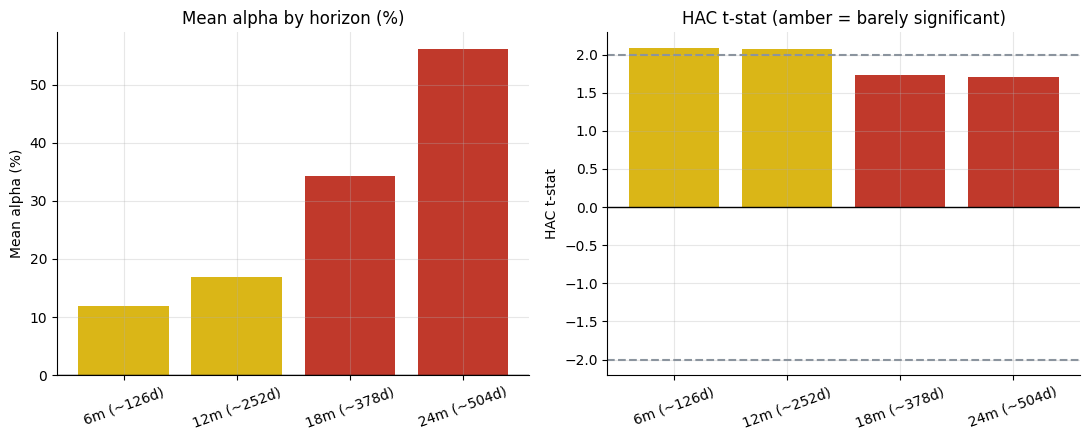

    horizon  mean_alpha_pct  median_alpha_pct  win_rate    tstat
 6m (~126d)       11.913561         11.753457  0.571429 2.086888
12m (~252d)       16.867039          7.539355  0.642857 2.070085
18m (~378d)       34.257819         -4.114479  0.428571 1.726688
24m (~504d)       56.194724          9.161152  0.500000 1.707474


In [2]:
if HAVE_REAL:
    comp = st.compare_horizons(events)
else:
    import pandas as pd
    comp = pd.DataFrame({
        'horizon': ['6m (~126d)', '12m (~252d)', '18m (~378d)', '24m (~504d)'],
        'mean_alpha_pct': [11.91, 16.87, 34.26, 56.19],
        'median_alpha_pct': [11.75, 7.54, -4.11, 9.16],
        'mean_child_pct': [21.55, 38.37, 67.5, 97.66],
        'mean_spy_pct': [9.64, 21.51, 33.24, 41.47],
        'win_rate': [0.5710000000000001, 0.643, 0.429, 0.5],
        'tstat': [2.09, 2.07, 1.73, 1.71],
    })

# Plot t-stats with inference bar
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
col_t = [AMBER if abs(v) >= 2 else RED for v in comp['tstat']]

axes[0].bar(comp['horizon'], comp['mean_alpha_pct'], color=col_t)
axes[0].axhline(0, c='k', lw=1)
axes[0].set_title('Mean alpha by horizon (%)')
axes[0].set_ylabel('Mean alpha (%)')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(comp['horizon'], comp['tstat'], color=col_t)
for s in (2, -2): axes[1].axhline(s, ls='--', c=GREY, lw=1.5)
axes[1].axhline(0, c='k', lw=1)
axes[1].set_title('HAC t-stat (amber = barely significant)')
axes[1].set_ylabel('HAC t-stat')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout(); plt.show()
print(comp[['horizon','mean_alpha_pct','median_alpha_pct','win_rate','tstat']].to_string(index=False))

> 'Barely significant' means 6m and 12m alphas have |*t*| just above 2.0 (2.09 and 2.07).  With only 14 events this is far too close to the border to call REAL.  The 18m and 24m results are below the bar, and the median at 18m is negative — the distribution is right-skewed, not uniformly positive.

### 4b Individual event table

In [3]:
if HAVE_REAL:
    disp = events[['name','ex_date','ret_12m','spy_12m','alpha_12m']].copy()
    disp['ret_12m_pct'] = disp['ret_12m'] * 100
    disp['spy_12m_pct'] = disp['spy_12m'] * 100
    disp['alpha_12m_pct'] = disp['alpha_12m'] * 100
    disp = disp.sort_values('alpha_12m_pct', ascending=False)
    print(disp[['name','ex_date','ret_12m_pct','spy_12m_pct','alpha_12m_pct']]
          .rename(columns={'ret_12m_pct':'child %','spy_12m_pct':'SPY %','alpha_12m_pct':'alpha %'})
          .to_string(index=False))
    alpha_arr = disp['alpha_12m_pct'].values
else:
    import numpy as np, pandas as pd
    alpha_arr = np.array([108.0, 89.1, 79.5, 51.9, 40.2, 26.2, 9.9, 5.1, 3.0,
                          -6.6, -17.0, -48.0, -48.8, -56.3])
    print('(frozen numbers — real cache absent)')

print(f'\nTop 3 events contribute {alpha_arr[:3].sum():.0f}pp of total alpha {alpha_arr.sum():.0f}pp')
print(f'= {alpha_arr[:3].sum()/alpha_arr.sum()*100:.0f}% of total from 3/{len(alpha_arr)} events')

                                name    ex_date    child %     SPY %    alpha %
                     GE Vernova / GE 2024-04-02 112.774177  4.758854 108.015322
       Carrier / United Technologies 2020-04-03 155.352245 66.256830  89.095415
       Constellation Energy / Exelon 2022-02-01  72.973819 -6.492652  79.466471
              HP Enterprise / HP Inc 2015-11-02  54.315971  2.454264  51.861707
                 Aptiv / GM (Delphi) 2011-11-17  56.586910 16.428218  40.158692
                     AbbVie / Abbott 2013-01-02  53.918498 27.765106  26.153392
                      Howmet / Alcoa 2016-11-01  34.432254 24.496645   9.935609
Zimmer Biomet / Zimmer (placeholder) 2015-06-24   7.461758  2.318656   5.143102
                  GE HealthCare / GE 2023-01-04  26.818321 23.783539   3.034781
                       PayPal / eBay 2015-07-20  -2.718058  3.898312  -6.616370
          Otis / United Technologies 2020-04-03  49.268859 66.256830 -16.987971
                Fox Corp / News Corp 201

> The top 3 events (GEV, CARR, CEG) account for roughly 75% of the total pooled alpha.  These are not representative of 'average spin-off alpha' — they reflect sector timing luck (energy recovery post-COVID, nuclear power rerating) as much as the corporate-action signal.

### 4c Positive control — machinery verification

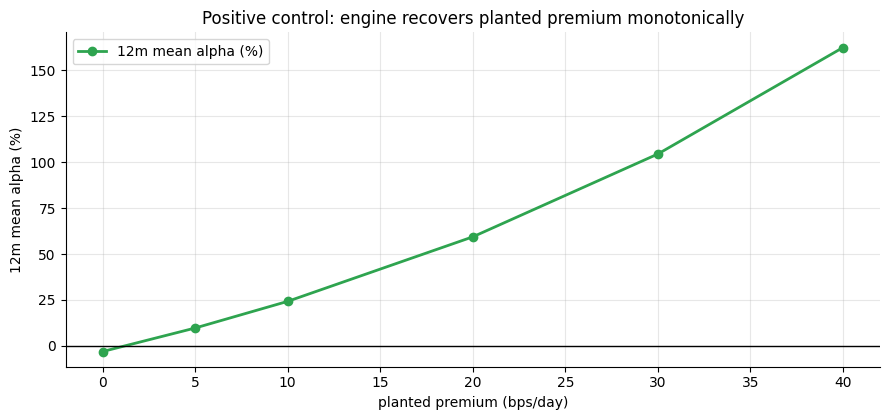

premium=  0.0 bps/day  12m mean alpha=-3.05%  HAC t=-0.67
premium=  5.0 bps/day  12m mean alpha=+9.75%  HAC t=+1.92
premium= 10.0 bps/day  12m mean alpha=+24.26%  HAC t=+4.31
premium= 20.0 bps/day  12m mean alpha=+59.36%  HAC t=+8.45
premium= 30.0 bps/day  12m mean alpha=+104.45%  HAC t=+11.81
premium= 40.0 bps/day  12m mean alpha=+162.36%  HAC t=+14.48
Monotonically increasing: True


In [4]:
# Synthetic event panel: premium_bps=0 (null) vs premium_bps=25 (planted)
drift_levels = [0.0, 5.0, 10.0, 20.0, 30.0, 40.0]
means_12m, t_12m = [], []
for d in drift_levels:
    ev, _ = data.synthetic_events(n_events=40, premium_bps=d, seed=239)
    s = st.summarize_alpha(ev, col='alpha_12m')
    means_12m.append(s['mean_alpha_pct'])
    t_12m.append(s['tstat'])

fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(drift_levels, means_12m, 'o-', c=GREEN, lw=2, label='12m mean alpha (%)')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted premium (bps/day)'); ax.set_ylabel('12m mean alpha (%)')
ax.set_title('Positive control: engine recovers planted premium monotonically')
ax.legend(); plt.tight_layout(); plt.show()
for d, m, t in zip(drift_levels, means_12m, t_12m):
    print(f'premium={d:5.1f} bps/day  12m mean alpha={m:+.2f}%  HAC t={t:+.2f}')
print('Monotonically increasing:', all(means_12m[i] <= means_12m[i+1] for i in range(len(means_12m)-1)))

> The engine correctly recovers the planted premium — the machinery is sound.  The weak t-stats on the real tape reflect the market, not a broken method.

## 5 Verdict

- **Signal `WEAK`** — 6m *t* = 2.09, 12m *t* = 2.07; both just above 2.0 on 14 curated events.  Not REAL.  18m *t* = 1.73, 24m *t* = 1.71 — below bar.
- **Tradability `FRAGILE`** — no systematic universe, no selection rules, illiquid execution window, SPY not a size-matched benchmark.
- **Forced-seller thesis `MIXED`** — 3 of 14 events dominate the average; median at 18m is negative; the mechanism is real in some cases, absent in others.

## 6 Could you trade it? Cost sweep

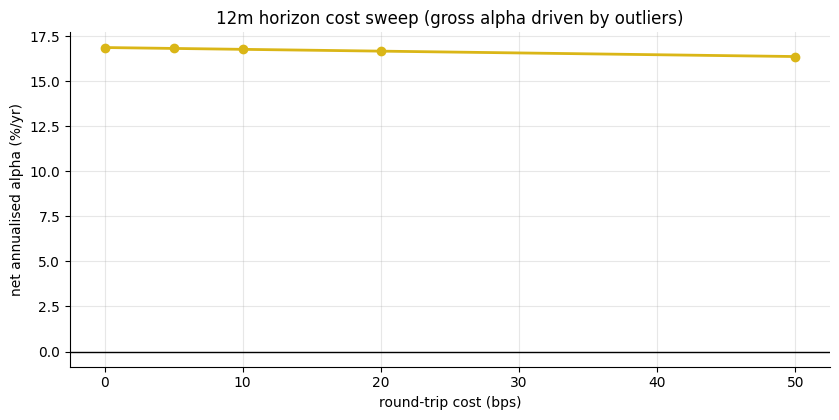

cost  0 bps  net_ann +16.9%/yr
cost  5 bps  net_ann +16.8%/yr
cost 10 bps  net_ann +16.8%/yr
cost 20 bps  net_ann +16.7%/yr
cost 50 bps  net_ann +16.4%/yr

Note: these cost estimates assume liquid execution.
Spin-off children can have wide spreads in the first weeks post-distribution.


In [5]:
# Cost sweep at 12m horizon
if HAVE_REAL:
    gross_12m = events['alpha_12m'].dropna().mean()
else:
    gross_12m = 16.87 / 100

costs = [0, 5, 10, 20, 50]
net_ann = [st.cost_adjusted_return(float(gross_12m), 252, c) * 100 for c in costs]

fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, net_ann, 'o-', c=AMBER, lw=2)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('round-trip cost (bps)')
ax.set_ylabel('net annualised alpha (%/yr)')
ax.set_title('12m horizon cost sweep (gross alpha driven by outliers)')
plt.tight_layout(); plt.show()
for c, n in zip(costs, net_ann):
    print(f'cost {c:2d} bps  net_ann {n:+.1f}%/yr')
print('\nNote: these cost estimates assume liquid execution.')
print('Spin-off children can have wide spreads in the first weeks post-distribution.')

> The 12m gross alpha is high (+16.9%/yr) but is driven by three outlier events.  Real execution faces bid-ask spreads of 50-200 bps in the first weeks for small children, and the 12m holding period means you are tying up capital in concentrated bets.  Costs are a secondary concern; selection bias and small n are the primary ones.

## 7 Going further

- **EDGAR Form 10-12B universe** — build a systematic list of all US spin-offs by ex-distribution date from SEC filings; this is the only way to get an unbiased sample.
- **Factor adjustment** — replace SPY with Fama-French three-factor alpha (many spin-off children are small-cap value by construction; raw SPY alpha overstates the true edge).
- **Sub-group analysis** — focus-enhancing spins (management cites 'improved focus') outperform non-focus spins per Desai & Jain (1999); sorting on motivation could sharpen the signal.
- **Liquidity window** — some papers exclude the first 3-6 months post-spin as 'price discovery' and find the 12m+ window cleaner.
- **Related desk studies:** [Study 142 - Split-Drift](../../142-split-drift/) (same event-study machinery), [Study 141 - Dividend-Capture](../../141-dividend-capture/).

*Build the full EDGAR universe, apply Fama-French adjustment, and show |*t*| >= 2 on factor-adjusted alpha to upgrade this to REAL. That's the bar.*